

Step 1: *Setting Up & Loading the Data*





In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Setting a style for better visualization
sns.set_style("whitegrid")
# This makes plots appear larger and easier to read
plt.rcParams['figure.figsize'] = (10, 6)

# Loading the dataset
file_name = 'spotify_data clean.csv'
df = pd.read_csv(file_name)

# Initial Inspection
print(" Initial Data Information ")
df.info()
print("\n First 5 Rows ")
print(df.head())

--- Initial Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8582 entries, 0 to 8581
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8582 non-null   object 
 1   track_name          8582 non-null   object 
 2   track_number        8582 non-null   int64  
 3   track_popularity    8582 non-null   int64  
 4   explicit            8582 non-null   bool   
 5   artist_name         8579 non-null   object 
 6   artist_popularity   8582 non-null   int64  
 7   artist_followers    8582 non-null   int64  
 8   artist_genres       5221 non-null   object 
 9   album_id            8582 non-null   object 
 10  album_name          8582 non-null   object 
 11  album_release_date  8582 non-null   object 
 12  album_total_tracks  8582 non-null   int64  
 13  album_type          8582 non-null   object 
 14  track_duration_min  8582 non-null   float64
dtypes: bool(1), float64(1)

Step 2: *Data Cleaning & Preprocessing*

In [ ]:
# 1. Date Conversion and Feature Extraction
# Converting 'album_release_date' from string to datetime format
df['album_release_date'] = pd.to_datetime(df['album_release_date'], errors='coerce')

# Extracting the year into a new column, which is essential for time-series analysis
df['release_year'] = df['album_release_date'].dt.year


# 2. Handling Missing Values
# The 'artist_genres' column has missing values (NaN). We fill them with 'Unknown' to keep all rows and allow us to analyze tracks without a specified genre.
df['artist_genres'].fillna('Unknown', inplace=True)

# Removing the 3 rows that are missing an 'artist_name'
df.dropna(subset=['artist_name'], inplace=True)

print("\n Data Cleaning Complete ")
print(df[['album_release_date', 'release_year', 'artist_genres']].head())


 Data Cleaning Complete 
  album_release_date  release_year                      artist_genres
0         2025-10-31          2025                         moombahton
1         2025-10-31          2025  country hip hop, southern hip hop
2         2025-10-31          2025                            Unknown
3         2025-10-31          2025                         moombahton
4         2025-10-30          2025                           dark r&b


/tmp/ipython-input-3321768066.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['artist_genres'].fillna('Unknown', inplace=True)


Step 3: *Exploratory Data Analysis (EDA) - Descriptive Statistics*

In [ ]:
# Descriptive statistics for numerical columns
print(" Descriptive Statistics ")
print(df[['track_popularity', 'artist_followers', 'track_duration_min']].describe())

# Finding the most popular track
most_popular_track = df.loc[df['track_popularity'].idxmax()]
print("\n Most Popular Track ")
print(f"Track: {most_popular_track['track_name']} by {most_popular_track['artist_name']} (Popularity: {most_popular_track['track_popularity']})")

# Finding the artist with the most followers
most_followed_artist = df.loc[df['artist_followers'].idxmax()]
print(f"Most Followed Artist: {most_followed_artist['artist_name']} (Followers: {most_followed_artist['artist_followers']:.0f})")

 Descriptive Statistics 
       track_popularity  artist_followers  track_duration_min
count       8579.000000      8.579000e+03         8579.000000
mean          52.355519      2.404312e+07            3.492803
std           23.818027      3.803580e+07            1.058084
min            0.000000      0.000000e+00            0.070000
25%           39.000000      4.653405e+05            2.880000
50%           58.000000      6.111369e+06            3.440000
75%           71.000000      2.728882e+07            3.990000
max           99.000000      1.455421e+08           13.510000

 Most Popular Track 
Track: Golden by HUNTR/X (Popularity: 99)
Most Followed Artist: Taylor Swift (Followers: 145542136)


Step 4: *Visualization (The Core Output)*

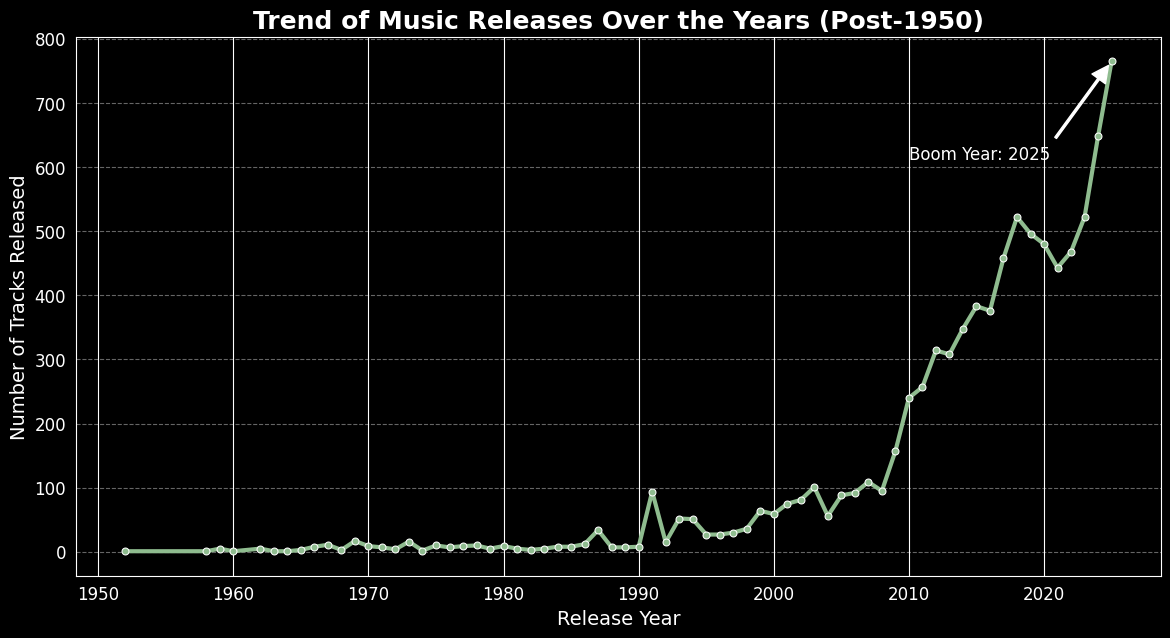

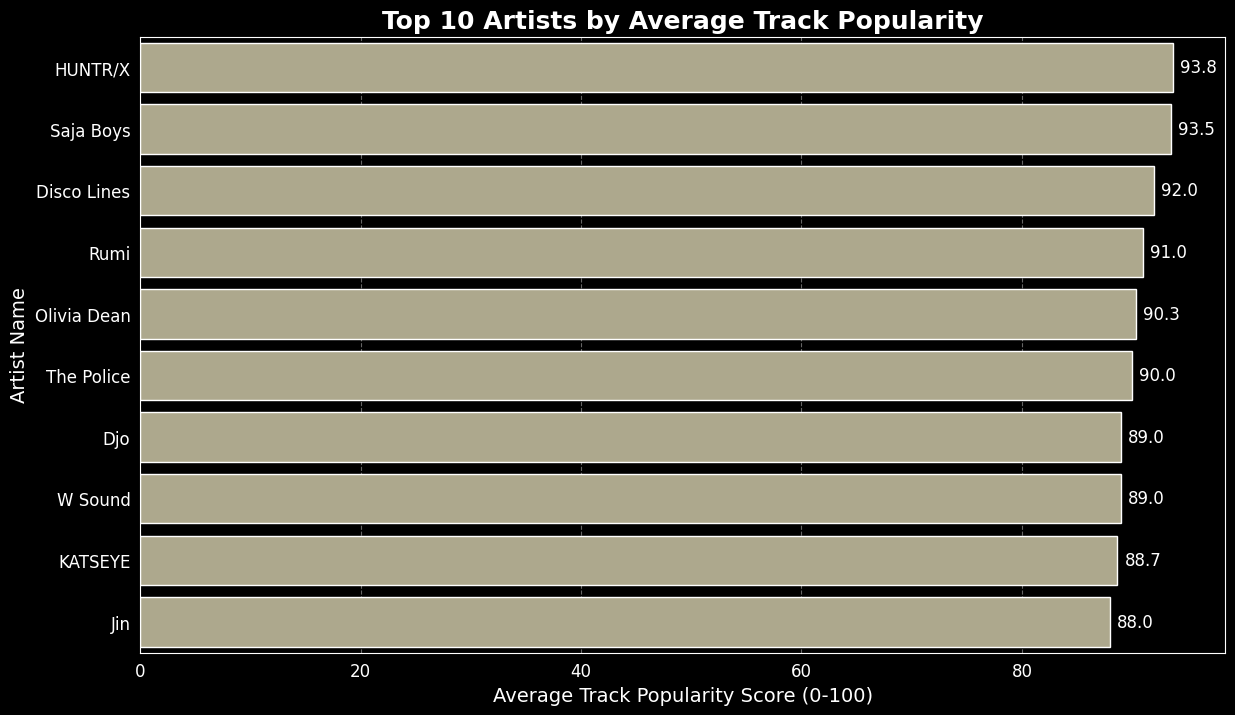

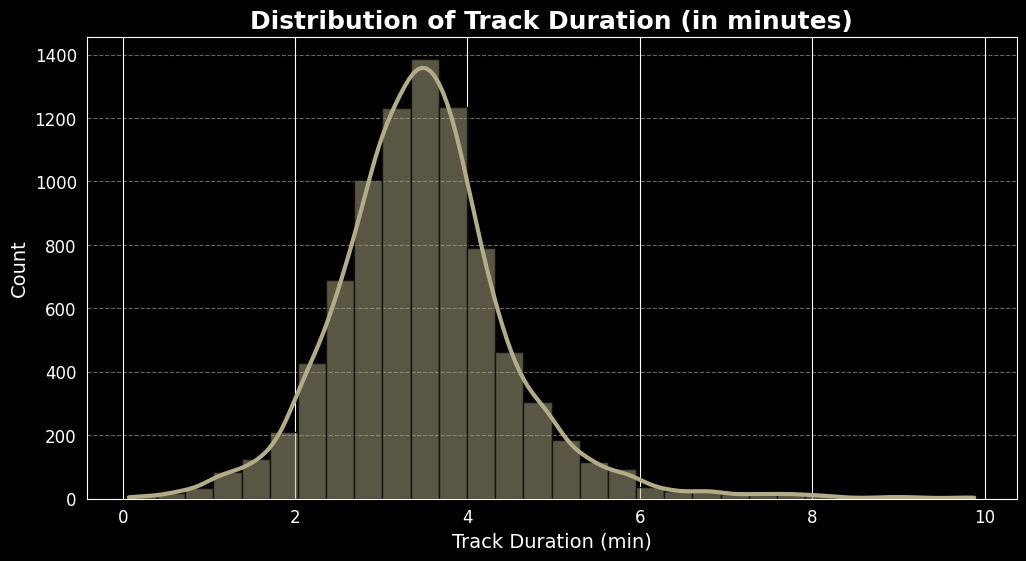

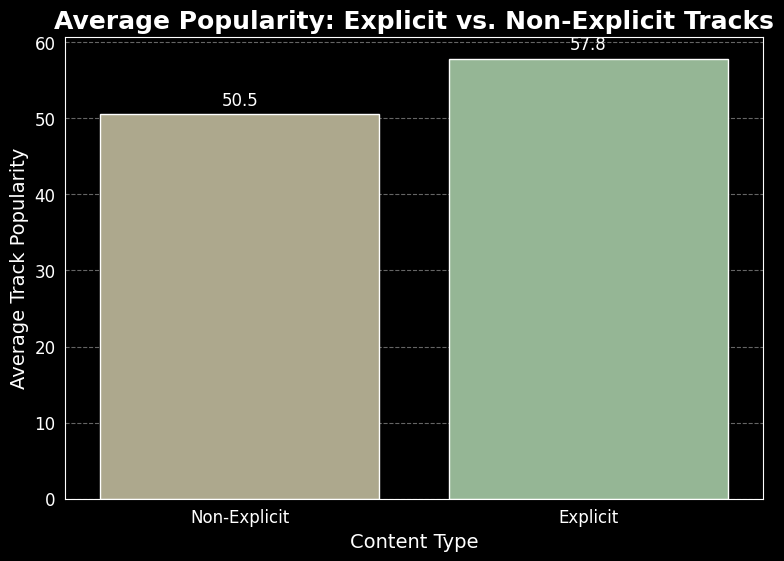

In [ ]:
# 1. GLOBAL THEME SETUP
plt.style.use('dark_background') # High-contrast dark theme
dark_sea_green = '#8FBC8F'       # PRIMARY COLOR
sage_green = '#B2AC88'           # SECONDARY COLOR
dark_bg = '#121212'

# Data Loading and Cleaning (Warning-free)
file_name = 'spotify_data clean.csv'
df = pd.read_csv(file_name)

df['album_release_date'] = pd.to_datetime(df['album_release_date'], errors='coerce')
df['release_year'] = df['album_release_date'].dt.year

# Fix: Using direct assignment to avoid chained assignment warning
df['artist_genres'] = df['artist_genres'].fillna('Unknown')
df = df.dropna(subset=['artist_name'])


# VIZ 1: Trend of Music Releases Over Time (Line Plot)
release_counts = df.groupby('release_year').size().reset_index(name='track_count')
release_counts = release_counts[release_counts['release_year'] >= 1950]

plt.figure(figsize=(14, 7))
ax1 = sns.lineplot(
    data=release_counts,
    x='release_year',
    y='track_count',
    color=dark_sea_green,
    linewidth=3,
    marker='o',
    markersize=5
)

plt.title('Trend of Music Releases Over the Years (Post-1950)', fontsize=18, fontweight='bold')
plt.xlabel('Release Year', fontsize=14)
plt.ylabel('Number of Tracks Released', fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=12)

# Highlighting the latest year with a text annotation
latest_year = release_counts['release_year'].max()
latest_count = release_counts['track_count'].max()
plt.annotate(
    f'Boom Year: {latest_year}',
    xy=(latest_year, latest_count),
    xytext=(latest_year - 15, latest_count * 0.8),
    arrowprops=dict(facecolor='white', shrink=0.05, width=1.5),
    fontsize=12,
    color='white'
)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.savefig('release_trend_sage_palette.png')
plt.show()


# VIZ 2: Top 10 Most Popular Artists (Horizontal Bar Chart)
artist_popularity = df.groupby('artist_name')['track_popularity'].mean().sort_values(ascending=False).head(10).reset_index(name='avg_popularity')

plt.figure(figsize=(14, 8))
ax2 = sns.barplot(
    data=artist_popularity,
    x='avg_popularity',
    y='artist_name',
    color=sage_green
)

# Adding data labels (for annotations)
for i in ax2.containers:
    ax2.bar_label(i, fmt='%.1f', padding=5, fontsize=12, color='white')

plt.title('Top 10 Artists by Average Track Popularity', fontsize=18, fontweight='bold')
plt.xlabel('Average Track Popularity Score (0-100)', fontsize=14)
plt.ylabel('Artist Name', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.savefig('top_artists_sage_palette.png')
plt.show()


# VIZ 3: Distribution of Track Duration (Histogram + KDE)
df_filtered_duration = df[df['track_duration_min'] < 10]

plt.figure(figsize=(12, 6))
ax3 = sns.histplot(
    df_filtered_duration['track_duration_min'],
    bins=30,
    kde=True,
    color=sage_green,
    edgecolor=dark_bg,
    line_kws={'color': dark_sea_green, 'linewidth': 3}
)

plt.title('Distribution of Track Duration (in minutes)', fontsize=18, fontweight='bold')
plt.xlabel('Track Duration (min)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.savefig('track_duration_sage_palette.png')
plt.show()


# VIZ 4: Popularity of Explicit vs. Non-Explicit Tracks (Comparison Bar Chart)
explicit_popularity = df.groupby('explicit')['track_popularity'].mean().reset_index(name='mean_popularity')
explicit_popularity['explicit_label'] = explicit_popularity['explicit'].apply(lambda x: 'Explicit' if x else 'Non-Explicit')

# Color palette: Using two shades for comparison
custom_palette_shades = [sage_green, dark_sea_green]

plt.figure(figsize=(9, 6))
ax4 = sns.barplot(
    data=explicit_popularity,
    x='explicit_label',
    y='mean_popularity',
    hue='explicit_label',
    palette=custom_palette_shades,
    legend=False
)

# Adding the mean popularity values directly onto the bars
for p in ax4.patches:
    ax4.annotate(
        f'{p.get_height():.1f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=12,
        color='white'
    )

plt.title('Average Popularity: Explicit vs. Non-Explicit Tracks', fontsize=18, fontweight='bold')
plt.xlabel('Content Type', fontsize=14)
plt.ylabel('Average Track Popularity', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.savefig('explicit_vs_popularity_sage_palette.png')
plt.show()